In [13]:
import numpy as np
import pandas as pd
import math
from uncertainties import unumpy as unp
from uncertainties import ufloat as uf
import numpy as np
import uncertainties.umath as umath

def print_uarrays(*arrays, names=None):
    """
    Print uncertainty arrays side-by-side, rounding to the first
    significant digit of the uncertainty.

    Parameters
    ----------
    *arrays : uarray-like
        Arrays of uncertainty-aware numbers.
    names : list[str], optional
        Column names printed above the data.
    """
    arrays = [np.asarray(a) for a in arrays]

    if names is not None and len(names) != len(arrays):
        raise ValueError("Number of names must match number of arrays.")

    if not arrays:
        return

    columns = []

    for arr in arrays:
        values = unp.nominal_values(arr)
        errors = unp.std_devs(arr)

        formatted = []

        for value, error in zip(values, errors):
            if error == 0:
                formatted.append(str(value))
                continue

            # First significant digit of uncertainty
            exponent = int(np.floor(np.log10(abs(error))))
            decimals = -exponent

            # Round both value and uncertainty to that decimal place
            value_r = round(value, decimals)
            error_r = round(error, decimals)

            formatted.append(f"{value_r:.{max(0, decimals)}f} ± "
                             f"{error_r:.{max(0, decimals)}f}")

        columns.append(formatted)

    # Column widths
    widths = [
        max(len(header), *(len(x) for x in column))
        for header, column in zip(
            names if names else [""] * len(columns), columns
        )
    ]

    # Header
    if names:
        print("  ".join(f"{name:>{width}}" for name, width in zip(names, widths)))
        print("  ".join("-" * width for width in widths))

    # Rows
    for row in zip(*columns):
        print("  ".join(f"{value:>{width}}" for value, width in zip(row, widths)))

In [3]:
class info:
    beaker_weight = uf(52.20, 0.01)/1000 #kg
    tube_length = uf(92.85,0.05)/100 #m
    P_rel_unc = 0.05 #%
    time_unc = 0.01 #s
    weight_unc = 0.01/1000 #kg
    water_density = 1000 #kg/m3
    g_acc = 9.81 #m/s2
    tube_diameter = uf(1.2, 0.1)/1000 #m
    tube_area = np.pi*tube_diameter*tube_diameter/4 #m2
    
raw_data = pd.read_csv('raw.dat', sep=',', skiprows=2)

print(raw_data)

   P1cm  P2cm   time  weight
0  93.0   3.1  35.38   67.58
1  71.0   2.5  42.36   66.43
2  56.8   1.8  42.56   63.34
3  49.5   1.2  45.75   62.47
4  31.5   0.6  45.17   58.90


In [27]:
data = pd.DataFrame()

data["Pressure_diff_Pa"] = info.water_density*info.g_acc*(raw_data["P1cm"] - raw_data["P2cm"])/100 #Pa
data["Pressure_unc"] = info.P_rel_unc*2*data["Pressure_diff_Pa"]
data["Flow_m3/s"] = ((raw_data["weight"])/1000 - info.beaker_weight.nominal_value)/(info.water_density*raw_data["time"])
data["Flow_unc"] =  data["Flow_m3/s"]*((1000*info.weight_unc+ info.beaker_weight.std_dev)/(info.beaker_weight.nominal_value) + info.time_unc/raw_data["time"])

print(data)


   Pressure_diff_Pa  Pressure_unc     Flow_m3/s      Flow_unc
0           8819.19       881.919  4.347089e-07  8.348371e-08
1           6719.85       671.985  3.359301e-07  6.449809e-08
2           5395.50       539.550  2.617481e-07  5.025496e-08
3           4738.23       473.823  2.244809e-07  4.309607e-08
4           3031.29       303.129  1.483285e-07  2.847668e-08


In [15]:
%%latex

The relation between flux ($Q$) and pressure variation ($\Delta P$) is given by
$$Q = \frac{\pi a⁴ \Delta P}{8 \eta l}$$.

With $\eta$ viscosity, $a=d/2$ radius of the tube, $l$ lenght of the tube. We linearize the equation, noting that $\frac{a⁴}{8} = \frac{d⁴}{2}$

$$\Delta P = \frac{2 \eta l}{\pi d⁴}Q$$.

With the slope $m = \frac{2 \eta l}{\pi d⁴}$, or

$$\eta = \frac{m \pi d⁴}{2l}$$

<IPython.core.display.Latex object>

0.070+/-0.023
158.04569839859323


<function matplotlib.pyplot.show(close=None, block=None)>

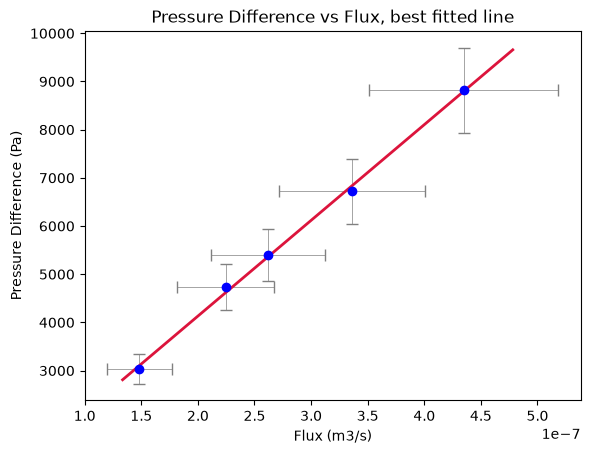

In [14]:
import matplotlib.pyplot as plt
from scipy import stats

P = data["Pressure_diff_Pa"].to_numpy()
P_err = data["Pressure_unc"].to_numpy()
Q = data["Flow_m3/s"].to_numpy()
Q_err = data["Flow_unc"].to_numpy()

res = stats.linregress(Q,P)

slope = uf(res.slope, res.stderr)
intercept = res.intercept

eta = slope*np.pi*umath.pow(info.tube_diameter,4)/(2*info.tube_length)

print(eta)
print(intercept)

x_line = np.linspace(Q.min()*0.9, Q.max()*1.1, 100)
y_line = res.slope*x_line + res.intercept
data_label = "data"
plt.errorbar(Q,P,xerr=Q_err, yerr=P_err, fmt='o', color='blue', ecolor='gray',
              capsize=4, elinewidth=0.5, label = data_label)

plt.plot(x_line, y_line, color='crimson', linewidth=2, 
         label="Best fit")


plt.xlabel('Flux (m3/s)')
plt.ylabel('Pressure Difference (Pa)')
plt.title('Pressure Difference vs Flux, best fitted line')

plt.show




In [26]:
# Reynold Numbers

v = unp.uarray(data["Flow_m3/s"].to_numpy(), data["Flow_unc"].to_numpy())/info.tube_area

Re = v*info.tube_diameter*info.water_density/eta

Vc = 2000*eta/(info.tube_diameter*info.water_density)

print(Re)
print(Vc)

[6.6188424260663945+/-3.0410836228662226
 5.11484507496749+/-2.3499596475828763
 3.985355862145987+/-1.831026330188814
 3.417927767239451+/-1.5703045590310063
 2.258438388554572+/-1.0376009653982747]
116+/-29
